# Comparaison des modèles (Students Social Media Addiction)

**Dataset :** Mobile Addiction  
**Variable cible :** `Addiction_Level` score d'addiction (Low, Moderate, Severe, High)

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

## 1 - Importation des bibliothèques

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)

from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree

import sys
sys.path.append('..')

from sklearn.model_selection import train_test_split
from models.encoder import labelEncoder, oneHotEncoder
from models.ACP import ACP

## 2 - Chargement et preprocessing

On charge le dataset, on supprime la colonne `User_ID` (identifiant sans valeur prédictive),  
et on convertit les variables textuelles en nombres avec `LabelEncoder`.  
Ensuite on sépare les données en 80% entraînement / 20% test.

In [2]:
df = pd.read_csv('BDD_initial/mobile_addiction_data.csv', sep='\t')
df = df.drop(columns=['User_ID'])

X_raw = df.drop(columns=['Addiction_Level'])
y_raw = df['Addiction_Level']

# Encoder y dans le bon ordre
le_y = LabelEncoder()
le_y.classes_ = np.array(['Low', 'Moderate', 'High', 'Severe'])
y = le_y.transform(y_raw)  # Low=0, Moderate=1, High=2, Severe=3

# Encoder X
X_le  = labelEncoder(X_raw.copy())
X_ohe = oneHotEncoder(X_raw.copy())
x_acp = ACP(X_ohe, n_components=50)

# Splits
X_train_le,  X_test_le,  y_train_le,  y_test_le  = train_test_split(X_le,  y, test_size=0.2, random_state=42)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y, test_size=0.2, random_state=42)
X_train_acp, X_test_acp, y_train_acp, y_test_acp = train_test_split(x_acp, y, test_size=0.2, random_state=42)

# label_encoders pour l'exemple étudiant
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_raw[col])
    label_encoders[col] = le

print('X_le  shape:', X_le.shape)
print('X_ohe shape:', X_ohe.shape)
print('X_acp shape:', x_acp.shape)
print('Train / Test:', X_train_le.shape[0], '/', X_test_le.shape[0])

X_le  shape: (3000, 33)
X_ohe shape: (3000, 22519)
X_acp shape: (3000, 50)
Train / Test: 2400 / 600


C:\Users\sidsm\AppData\Local\Temp\ipykernel_19472\2596468197.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include='object').columns.tolist()


## 3. Entraînement des modèles

Chaque modèle est dans un fichier séparé dans `models/`.  
La fonction `run(X_train, X_test, y_train, y_test)` retourne un dictionnaire avec les métriques.

> **Pour ajouter un modèle** : importer sa fonction `run` et l'ajouter au dictionnaire `modeles`.

In [ ]:
import sys
sys.path.append('..')

from models.random_forest_rgs_v2 import run as run_rf
from models.xgboost_rgs_v2 import run as run_xgb_rgs
from models.xgboost_rgs import run as run_xgb
from models.knn_rgs import run as run_knn
from models.naive_bayes_rgs_v2 import run as run_nb_rgs

modeles = {
    'KNN'          : run_knn,
    'xgboost rgs'  : run_xgb_rgs,
    'Naive Bayes rgs'  : run_nb_rgs,
    'XGBoost'      : run_xgb,
    'Random Forest': run_rf,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f'Entraînement : {nom}...')
    resultats[f'{nom} (LE)']  = run_fn(X_train_le,  X_test_le,  y_train_le, y_test_le)
    resultats[f'{nom} (ACP)'] = run_fn(X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe)
    resultats[f'{nom} (ACP)'] = run_fn(X_train_acp, X_test_acp, y_train_acp, y_test_acp)



    print(f"  LE  R²: {resultats[f'{nom} (LE)']['optimized']['r2']:.4f}")
    print(f"  ACP R²: {resultats[f'{nom} (ACP)']['optimized']['r2']:.4f}")

print('\nTerminé.')

Entraînement : KNN...
  LE  R²: -0.0601
  ACP R²: -0.0861
Entraînement : xgboost rgs...
  LE  R²: -0.0104
  ACP R²: -0.0192
Entraînement : Naive Bayes rgs...
  LE  R²: -0.0151
  ACP R²: -0.1454
Entraînement : XGBoost...


## 4. Tableau comparatif

On compare les modèles sur trois métriques :
- **R²** : proportion de variance expliquée (plus c'est proche de 1, mieux c'est)
- **MAE** : erreur moyenne en points de score
- **RMSE** : similaire au MAE, mais pénalise plus les grandes erreurs

In [15]:
rows = []
for nom, res in resultats.items():
    opt = res['optimized']
    rows.append({
        'Modèle': nom,
        'R²'    : round(opt['r2'],   4),
        'MAE'   : round(opt['mae'],  4),
        'RMSE'  : round(opt['rmse'], 4),
    })

df_comparaison = pd.DataFrame(rows).sort_values('R²', ascending=False).set_index('Modèle')
df_comparaison

,R²,MAE,RMSE
Modèle,,,
Random Forest (LE),0.6283,1.5008,1.9327
xgboost rgs (LE),0.6227,1.5132,1.9472
XGBoost (LE),0.6227,1.5132,1.9472
Naive Bayes rgs (LE),0.6041,1.5275,1.9949
KNN (LE),0.4884,1.6751,2.2676
xgboost rgs (ACP),0.0954,2.2839,3.0153
XGBoost (ACP),0.0954,2.2839,3.0153
Naive Bayes rgs (ACP),0.0940,2.2787,3.0175
Random Forest (ACP),0.0909,2.2938,3.0228


## 5. Visualisation des métriques

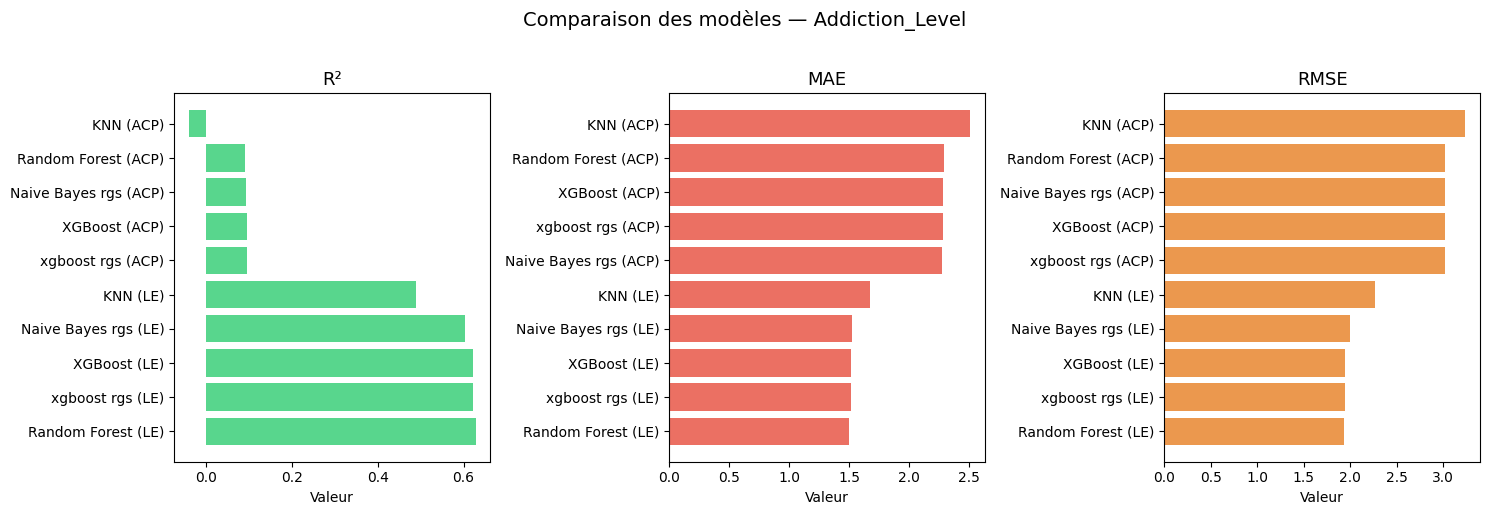

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('R²', '#2ecc71', False), ('MAE', '#e74c3c', True), ('RMSE', '#e67e22', True)]

for ax, (metric, color, ascending) in zip(axes, metrics):
    vals = df_comparaison[metric].sort_values(ascending=ascending)
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Valeur')

plt.suptitle('Comparaison des modèles — Addiction_Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Exemple d'application

On crée un profil d'étudiant fictif et on demande au modèle de prédire son score d'addiction.  
Les variables catégorielles sont encodées avec les mêmes `LabelEncoder` utilisés à l'étape 2.

In [19]:
print(df.columns.tolist())

['id', 'name', 'age', 'gender', 'country', 'city', 'education_level', 'employment_status', 'annual_income_usd', 'marital_status', 'children_count', 'smokes_per_day', 'drinks_per_week', 'age_started_smoking', 'age_started_drinking', 'attempts_to_quit_smoking', 'attempts_to_quit_drinking', 'has_health_issues', 'mental_health_status', 'exercise_frequency', 'diet_quality', 'sleep_hours', 'bmi', 'social_support', 'therapy_history', 'addict_smoke', 'addict_drink']


In [ ]:
etudiant = {
    'Country'                            : 'USA',
    'Age'                                : 20,
    'Gender'                             : 'Male',
    'Occupation'                         : 'Student',
    'Education_Level'                    : 'High School',
    'Income_USD'                         : 15000,
    'Daily_Social_Media_Usage_Hours'     : 5.0,
    'Phone_Unlocked_Per_Day'             : 50,
    'Social_Media_Usage_Hours_Per_Day'   : 4.0,
    'Gaming_Usage_Hours'                 : 1.0,
    'Streaming_Usage_Hours'              : 0.5,
    'Messaging_Usage_Hours'              : 0.5,
    'Work_Related_Usage_Hours'           : 0.0,
    'Sleep_Hours'                        : 6.0,
    'Physical_Activity_Hours'            : 1.0,
    'Mental_Health_Score'                : 13.0,
    'Depression_Score'                   : 20.0,
    'Anxiety_Score'                      : 15.0,
    'Stress_Level'                       : 18.0,
    'Relathionship_status'               : 'Single',
    'Has_Children'                       : 'No',
    'Urban_or_Rural'                     : 'Urban',
    'Time_Spent_With_Family_Hours_Per_Day': 1.0,
    'Online_Shopping_Hours'              : 0.5,
    'Internet_Connection_Type'           : 'WiFi',
    'Primary_Device_Brand'               : 'Apple',
    'Has_Screen_Time_Managment_App'      : 'No',
    'Monthly_Data_Usage_GB'              : 10.0,
    'Has_Night_Mode_On'                  : 'Yes',
    'Age_First_Phone'                    : 12,
    'Push_Notifications_Per_Day'         : 30,
    'Tech_Savviness_Score'               : 7.0,
    'Addiction_screen'                   : 1.0,
}

# Encodage
etudiant_enc = {}
for col, val in etudiant.items():
    if col in label_encoders:
        etudiant_enc[col] = label_encoders[col].transform([val])[0]
    else:
        etudiant_enc[col] = val

X_etudiant = pd.DataFrame([etudiant_enc])[X_le.columns]

# Meilleur modèle
best_rf = resultats['Random Forest (LE)']['model']

# Prédiction (résultat encodé → label original)
pred_encoded = best_rf.predict(X_etudiant)[0]
pred_label   = le_y.inverse_transform([round(pred_encoded)])[0]

print("=== Profil de l'étudiant ===")
for k, v in etudiant.items():
    print(f"  {k:<40} : {v}")

print(f"\n  Niveau d'addiction prédit : {pred_label}")

KeyError: "None of [Index(['id', 'name', 'age', 'gender', 'country', 'city', 'education_level',\n       'employment_status', 'annual_income_usd', 'marital_status',\n       'children_count', 'drinks_per_week', 'age_started_smoking',\n       'age_started_drinking', 'attempts_to_quit_smoking',\n       'attempts_to_quit_drinking', 'has_health_issues',\n       'mental_health_status', 'exercise_frequency', 'diet_quality',\n       'sleep_hours', 'bmi', 'social_support', 'therapy_history',\n       'addict_smoke', 'addict_drink'],\n      dtype='object')] are in the [columns]"